# Lab 4 - Validation & Experimentation

**Due: March 31st at 11:59pm**

## Learning Goals:

The goal of this lab is to practice using good experimental design and methodology to train and test classifiers, as well as tune hyperparameters.  You will write some simple code to try doing this yourself, and you will also use the tools built into scikit-learn, numpy, and scipy-stats.

As with any programming assignment, you'll also be practicing and improving your general CS skills, like problem decomposition, algorithmic thinking, implementation and testing, language syntax, etc.. Here are some of the specific things you should learn while completing this assignment:

   * How to load and use python libraries to train and evaluate ML models in a more rigorous fashion (i.e. going beyond a single train/test split)
   * The impact of a random seed value, and how to mitigate this impact
   * How to measure performance in different ways (beyond just accuracy)
   * How to use your understanding of a data set to figure out what performance measures are appropriate
   * How to work independently to make choices about testing and applying machine learning methods
   * Utilize held-aside tuning sets to choose hyperparameters and balance bias/variance
   * Compare methods on several data sets using $k$-fold cross validation
   * Analyze experiments using several methodologies, including statistical tests and validation curves
   * Learn to read and use the scikit-learn API Reference and User's Guide


This lab is intended to be done with a partner (i.e. teams of two); partners will be assigned based on your response to the partner preference survey.

You'll have approximately two weeks to complete this lab.

**NOTE: this lab comes with two extra notebook files that contain examples; use them for reference.  This notebook is the only one that needs to be modified for the assignment**

In [1]:
# CPSC 66 - Machine Learning
# Lab 4
# Scaffolding by Prof. Ben Mitchell & Ameet Soni
# Assignment completed by: Amirkhan Aidarkhan, Kevin Li
# Resources used: 
#   <List any resources you used beyond the ones posted on Blackboard>
#   <This can include books, websites, other students, etc.>

In [2]:
# import math and numpy first
import math
import numpy as np
# import scipy for stats package
import scipy
# import some data and classifiers to play with; you may want to add more
from sklearn import datasets
from sklearn import neighbors
from sklearn import tree
from sklearn import ensemble
from sklearn.linear_model import SGDClassifier
from sklearn import svm
# import some validation tools
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Part 1: Multiple classifiers using SciKit Learn

### Load some data

SciKit Learn comes with a number of "built-in" datasets beyond the Iris dataset we've been using (see https://scikit-learn.org/stable/datasets/index.html for a full list).  For this assignment, we will load several datasets, and compare the performance of several classifiers on each of them.

First we'll load the iris dataset again, since it's small and easy to work with.  Feel free to try replacing this with a different data set to see what happens, though I recommend getting things working first with this one (since it's small enough that everything runs fast).

In [3]:
#load the iris dataset and split it into train and test sets
iris = datasets.load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.4, random_state=2)

## Create a Nearest Neighbor classifier
Create a nearest neighbor classifier using SKLearn just like we did in Lab 1; here, we will use it as a baseline for comparing other classifiers.  Be sure to train it and then evaluate its performance on the testing data (again, you should be able to use code from the previous assignment with little or no modification to do this).  Use an n_neighbors value of 1.  This should give you the same accuracy as you got in the first assignment.

Once you've got it working, try changing the `random_state` value in the [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function call (above) to 1 and re-running your nearest-neighbor classifier.  Try it again with a value of 2.  Write down each of the accuracies below; the first one has been done for you.

In [4]:
# create, train, and test a nearest neighbor classifier

iris_knn = neighbors.KNeighborsClassifier(n_neighbors=1)
iris_knn.fit(X_train, y_train)
iris_knn.score(X_test, y_test)

0.9666666666666667

**Question 1: accuracy of nearest neighbor for different random seed values**

seed=0, accuracy = 0.9166666666666666

seed=1, accuracy = 0.9666666666666667

seed=2, accuracy = 0.9666666666666667

## Create a Decision Tree

Create a decision tree, using [`tree.DecisionTreeClassifier()`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) as your classifier.  Train and test as before.

In [5]:
# create, train, and test

iris_tree = tree.DecisionTreeClassifier(random_state=0)
iris_tree.fit(X_train, y_train)
iris_tree.score(X_test, y_test)

0.9333333333333333

**Question 2: accuracy of decision tree for different random seed values**

seed=0, accuracy = 0.95

seed=1, accuracy = 0.9666666666666667

seed=2, accuracy = 0.9333333333333333

## Create a Logistic Regression classifier
Create a logistic regression classifier using  `SGDClassifier` like we did in the Logistic Regression lab (you can use the sklearn implementation, you don't need to import and use your own implementation of LR)

In [6]:
# create, train, and test

iris_log = SGDClassifier(loss='log_loss')
iris_log.fit(X_train, y_train)
iris_log.score(X_test, y_test)

0.9

**Question 3: accuracy of Logistic Regression for different random seed values**

seed=0, accuracy = 0.85

seed=1, accuracy = 0.7333333333333333

seed=2, accuracy = 0.7333333333333333

## Create a Random Forest classifier
Create a [RandomForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) classifier using `ensemble.RandomForestClassifier` (again, just go ahead and use the sklearn version, you don't need to use the one you wrote)

In [7]:
# create, train, and test

iris_forest = RandomForestClassifier()
iris_forest.fit(X_train, y_train)
iris_forest.score(X_test, y_test)

0.9333333333333333

**Question 4: accuracy of Random Forest for different random seed values**

seed=0, accuracy = 0.9333333333333333

seed=1, accuracy = 0.9666666666666667

seed=2, accuracy = 0.9333333333333333

## Create a Support Vector Machine classifier
Create a [SVM](https://scikit-learn.org/stable/modules/svm.html) classifier using `svm.SVC`.  We didn't implement this algorithm, but we did talk about it in class.


In [8]:
iris_svm = svm.SVC(decision_function_shape='ovo')
iris_svm.fit(X_train, y_train)
iris_svm.score(X_test, y_test)

0.9333333333333333

**Question 5: accuracy of SVM for different random seed values**

seed=0, accuracy = 0.9333333333333333

seed=1, accuracy = 0.9833333333333333

seed=2, accuracy = 0.9333333333333333

# Part 2: Repeated hold-out validation and Computing Statistics
We've done 'hold-out' validation using the `train_test_split` method, but we've used a fixed seed value.  In the previous part, we manually changed the seed for the random-number generator to get different train/test splits so we could see how the performance of our classifiers changed.  This time, let's write a loop to do the same thing for us.  Copy your code from the previous section to split the data 60/40 and then train and test a decision tree, and put it inside a `for`-loop that runs 10 times.  Each time, seed the `train_test_split` function with the current loop iteration counter (i.e. the first time through, `train_test_split` should be 0, the second time through it should be 1, etc.).  The result should be 10 accuracy scores, which should be stable (i.e. if you re-run the cell, you get the same 10 numbers)

In [9]:
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.4, random_state=i)
    iris_tree = tree.DecisionTreeClassifier(random_state=0)
    iris_tree.fit(X_train, y_train)

    print("train test seed:",i,"score:",iris_tree.score(X_test, y_test))

train test seed: 0 score: 0.95
train test seed: 1 score: 0.9666666666666667
train test seed: 2 score: 0.9333333333333333
train test seed: 3 score: 0.95
train test seed: 4 score: 0.9666666666666667
train test seed: 5 score: 0.9666666666666667
train test seed: 6 score: 0.95
train test seed: 7 score: 0.95
train test seed: 8 score: 0.9333333333333333
train test seed: 9 score: 0.9666666666666667


## Random seed

Now try making a copy of the loop, but leave off the `random_state` argument entirely.  This version of the loop should give you output that is generally similar to the previous one, but each time you re-run it, you should get different scores.  This is because the 'default' for the `train_test_split` function is to not use a static seed value, so every time you run it you'll get a different result.  Read more [here](https://scikit-learn.org/stable/glossary.html#term-random_state).

In [10]:
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.4, random_state=i)
    iris_tree = tree.DecisionTreeClassifier()
    iris_tree.fit(X_train, y_train)

    print("train test seed:",i,"score:",iris_tree.score(X_test, y_test))

train test seed: 0 score: 0.95
train test seed: 1 score: 0.9666666666666667
train test seed: 2 score: 0.9333333333333333
train test seed: 3 score: 0.95
train test seed: 4 score: 0.9666666666666667
train test seed: 5 score: 0.9666666666666667
train test seed: 6 score: 0.9666666666666667
train test seed: 7 score: 0.9333333333333333
train test seed: 8 score: 0.9333333333333333
train test seed: 9 score: 0.9666666666666667


## Computing Statistics

Make copy of the previous cell (i.e. the loop without fixed seeds), but this time instead of printing the individual scores, store them in a list.  The easiest way to do this is to start with an empty list (e.g. `myList = []`), and then add numbers using the `.append()` method.  After the loop is done, print out your list to be sure it looks the way you expect (you should be able to do this with a single print, e.g. `print(myList)`)

In [11]:
scoreslist = []
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.4, random_state=i)
    iris_tree = tree.DecisionTreeClassifier()
    iris_tree.fit(X_train, y_train)

    scoreslist.append(iris_tree.score(X_test, y_test))

print(scoreslist)

[0.95, 0.9666666666666667, 0.9333333333333333, 0.95, 0.9666666666666667, 0.95, 0.9666666666666667, 0.9333333333333333, 0.9333333333333333, 0.9666666666666667]


### Mean
Compute the mean (average) of the list of numbers you made in the previous step; this is the average accuracy over your 10 trials

In [12]:
def mean(nums):
    """
    Calculate the arithmetic mean of a list of numbers.
    
    Parameters:
    -----------
    nums : list or array-like
        A collection of numerical values
        
    Returns:
    --------
    float
        The arithmetic mean of the input numbers
    """
    total = 0
    for num in nums:
        total += num
    return total / len(nums)

### Variance & Standard Deviation
Now compute the variance and standard deviation of your list of accuracies.  The standard deviation is the square root of the variance, and the variance is basically just the average squared differences from the mean.  

This will be a bit like the loop you wrote to calculate Euclidean distance, only now you're subtracting the mean rather than a coordinate of another point, and you're going to be dividing by the number of items in the list minus one before you take the square root.  


Note that the symbol for standard deviation is $\sigma$ (the greek letter 'sigma'); there's no standard symbol for variance, it's just $\sigma^2$.  Here's the equations, where $n$ is the number of items in the list, $x_i$ is the $i$-th element of the list, and $\mu$ is the mean:

$$ \sigma^2 = \frac{1}{n-1} \sum_{i=1}^n (x_i - \mu)^2 $$

$$ \sigma = \sqrt{\sigma^2} $$

**Note** if you look this up, you may sometimes see $1/n$ and other times see $1/(n-1)$ in the first equation; in statistics, these are referred to as the 'sample' and 'population' versions, but for our purposes $n$ is typically large enough that the difference is mostly irrelevant.  Still, if a library is giving you an answer that's _almost_ the same as your implementation, it may be due to the library using the other version.

In [13]:
def variance(nums):
    """
    Calculate the sample variance of a list of numbers.
    
    Parameters:
    -----------
    nums : list or array-like
        A collection of numerical values
        
    Returns:
    --------
    float
        The sample variance using n-1 in the denominator (Bessel's correction)
    """
    n = len(nums)
    summation = 0
    avg = mean(nums)
    for num in nums:
        summation += (num - avg)**2
    return summation / (n - 1)

def standard_deviation(nums):
    """
    Calculate the sample standard deviation of a list of numbers.
    
    Parameters:
    -----------
    nums : list or array-like
        A collection of numerical values
        
    Returns:
    --------
    float
        The sample standard deviation (square root of variance)
    """
    return variance(nums)**0.5

print("varriance: ",variance(scoreslist))
print("standard deviation: ",standard_deviation(scoreslist))

varriance:  0.00021296296296296295
standard deviation:  0.014593250596181885


### Stats using scipy
To check and see if you've calculated your statistics correctly, you can use the `scipy.stats` library.  In particular, if you call the method `scipy.stats.describe()` and give it a list of numbers as an argument, it will report a variety of statistics, including mean and variance.  Make sure that these values match the ones you've calculated above.  See https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.describe.html#scipy.stats.describe for documentation.

In the future, it's fine to use the stats library to do this kind of thing for you, but it's a lot easier to understand the numbers coming out of the stats library once you've written code to calculate those numbers yourself.  You can also use this as a reference implementation, to check that your own code produces the same values.

In [14]:
scipy.stats.describe(scoreslist)

DescribeResult(nobs=np.int64(10), minmax=(np.float64(0.9333333333333333), np.float64(0.9666666666666667)), mean=np.float64(0.9516666666666665), variance=np.float64(0.00021296296296296295), skewness=np.float64(-0.1884300309168283), kurtosis=np.float64(-1.5261499684940218))

# Part 3: K-Fold Cross-validation

Now we'll use scikit-learn to do some more complicated types of validation.  Repeatedly re-spliting the data is okay, but it's not ideal from a statistical reliability standpoint (as we discussed in class).  Therefore, a better practice is to use k-fold cross-validation, as shown in this example.  Note the parameter `cv=5`; this is how many 'folds' to use, and will also be how many scores you get out.

In [15]:
clf = neighbors.KNeighborsClassifier(n_neighbors=1, metric='euclidean')
scores = cross_val_score(clf, iris.data, iris.target, cv=5)
scores

array([0.96666667, 0.96666667, 0.93333333, 0.93333333, 1.        ])

### Statistics on the accuracies

Since `cross_val_score` returns a numpy array, we can use numpy methods to get the mean and standard deviation:

In [16]:
print('mean accuracy:', scores.mean(), ', stdDev:', scores.std())

mean accuracy: 0.96 , stdDev: 0.024944382578492935


We can also use scipy stats to calculate statistics on numpy arrays:

In [17]:
scipy.stats.describe(scores)

DescribeResult(nobs=np.int64(5), minmax=(np.float64(0.9333333333333333), np.float64(1.0)), mean=np.float64(0.96), variance=np.float64(0.0007777777777777774), skewness=np.float64(0.343621596744551), kurtosis=np.float64(-1.1530612244897933))

## Repeated K-fold (aka N-by-K fold)
If you try running the cross-validation cell multiple times, you'll notice you get the same values back every time.  That's because `cross_val_score` doesn't shuffle the data randomly every time you call it.  If we actually want to re-run cross-validation with a new set of point-to-fold assignmenst, we can use the function `RepeatedKFold`, to get a set of folds, and then hand it to `cros_val_score` like this:

In [18]:
rkf = RepeatedKFold(n_splits = 5, n_repeats = 3)
scores2 = cross_val_score(clf, iris.data, iris.target, cv = rkf)
scores2

array([1.        , 0.9       , 0.93333333, 0.93333333, 1.        ,
       0.96666667, 0.96666667, 0.86666667, 0.96666667, 1.        ,
       1.        , 0.96666667, 0.93333333, 0.9       , 1.        ])

In [19]:
print('mean accuracy:', scores2.mean(), ', stdDev:', scores2.std())

mean accuracy: 0.9555555555555556 , stdDev: 0.0415739709641549


# Try using N-by-K to compare some classifiers

Previously, we tried to compare some classifiers by hand; now, lets use cross-validation and statistics.

First, we'll run 5-fold cross-validation with 4 repeats to train and test a Nearest Neighbor classifier and a Decision Tree.  Each should give you an array of 20 accuracy values.  Print the mean and standard deviation for each classifier, then print the difference between the means. 

In [20]:
rkf = RepeatedKFold(n_splits = 10, n_repeats = 10)

nn = neighbors.KNeighborsClassifier(n_neighbors=1, metric='euclidean')
dt = tree.DecisionTreeClassifier()

nnScores = cross_val_score(nn, iris.data, iris.target, cv = rkf)
dtScores = cross_val_score(dt, iris.data, iris.target, cv = rkf)

print('Nearest Neighbor: mean =', nnScores.mean(), ', stdDev =', nnScores.std())
print('Decision Tree: mean =', dtScores.mean(), ', stdDev =', dtScores.std())
print('Difference between means:', dtScores.mean() - nnScores.mean())


Nearest Neighbor: mean = 0.9560000000000002 , stdDev = 0.0463992337101475
Decision Tree: mean = 0.9473333333333334 , stdDev = 0.05601190349678657
Difference between means: -0.008666666666666822


## Compare different values of K and N

Repeat the above experiment using the values of K and N below, and report the mean, stdDev and differece between the means for each (alternatively, you could write a loop to automate this process).  The first row has been completed for you (note that your numbers may be slightly different, since this is a stochastic process).  Also notice how long these take to finish (though you don't need to write that down).  Once the table is complete, look at it and try to see what patterns you can spot.

Remember that we're working with a pretty trivial toy problem here; the point is the process and methodology, not the exact magnitude of the scores.

_NOTE: please limit values to a reasonable number of sig figs_

***

Folds | Repeats  |   NN-mean  |  NN-stdev  | DT-mean   |  DT-stdDev   |  difference   |
------|----------|------------|------------|-----------|--------------|---------------|
5     |      4   |    0.957   |   0.035    |  0.943    |   0.038      |     -0.02     |
2     |      10  |    0.957   |   0.018    |     0.936     |    0.024        |     -0.02        | 
10    |      2   |      0.960    |      0.044   |    0.951     |    0.055         |     -0.01        |
10    |      10  |      0.958     |      0.047     |    0.948      |    0.064         |     -0.01         |

# Part 4: Alternative Metrics

Up until now, we've just worked with overall accuracy as our only way of "scoring" the performance of a classifier.  Now, we will try out some alternative tools for evaluating classifier performance.  In addition to the `.scores()` method, scikit-learn classifiers have a `.predict()` method which takes in a set of examples as an argument, and returns an array with the predicted labels for those examples.  Here's an example:

In [21]:
train, test, trainLabels, testLabels = train_test_split(iris.data, iris.target, test_size=0.4, random_state=0)
clf = neighbors.KNeighborsClassifier(n_neighbors=1, metric='euclidean')
clf.fit(train, trainLabels)
predictions = clf.predict(test)
print('predicted labels: ', predictions)
print('true labels: ', testLabels)

predicted labels:  [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2 1 1 2 0 2 0 0 1 2 2 1 2 1 2 1 1 1 1 1 2 1 2]
true labels:  [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 1 1 1 2 0 2 0 0 1 2 2 2 2 1 2 1 1 2 2 2 2 1 2]


## Confusion Matrix

By comparing the predicted labels to the 'true' labels, we could easily compute accuracy like we've done in the past.  This time, however, we want to drill down and get more details, so we're going to build a confusion matrix.

A confusion matrix works by making a 2D array (i.e. a matrix), with the rows corresponding to 'true' class labels and the columns corresponding to 'predicted' class labels.  You just need to loop over the pairs of corresponding true/predicted labels, and add to the count in the corresponding cell of the array.

**NOTE:** try to write this as a reasonably generic function; i.e. don't hardcode values so it only works for this particular dataset.

In [22]:
def confusion_matrix(testLabels, prediction):
    """
    Create a confusion matrix comparing predicted labels to true labels.
    
    Parameters:
    -----------
    testLabels : array-like
        The true labels from the test dataset
    prediction : array-like
        The predicted labels from the classifier
        
    Returns:
    --------
    matrix : numpy.ndarray
        A 2D confusion matrix where matrix[i][j] represents the count
        of samples with true label i that were predicted as label j
    """
    labels = sorted(set(testLabels))
    matrix = np.zeros((len(labels), len(labels)))
    for test, predict in zip(testLabels, prediction):
        matrix[test][predict] += 1
    return matrix
confusion_matrix(testLabels,predictions)

array([[16.,  0.,  0.],
       [ 0., 22.,  1.],
       [ 0.,  4., 17.]])

### Confusion Matrix using scikit-learn

We can also ask scikit-learn to generate a confusion matrix for us, as the following example shows.  Your own confusion matrix should look like the one produced by the library.

In [23]:
confMat = confusion_matrix(testLabels, predictions)
print(confMat)

[[16.  0.  0.]
 [ 0. 22.  1.]
 [ 0.  4. 17.]]


## Fancy Graphics

It's also possible to use Python's plotting tools to make fancy graphical versions of a confusion matrix; the following example is adapted from http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html.

In [24]:
import matplotlib.pyplot as plt
import itertools
%matplotlib widget

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')



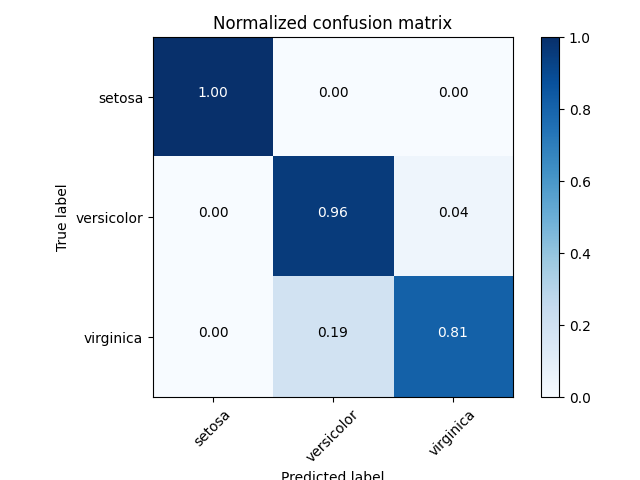

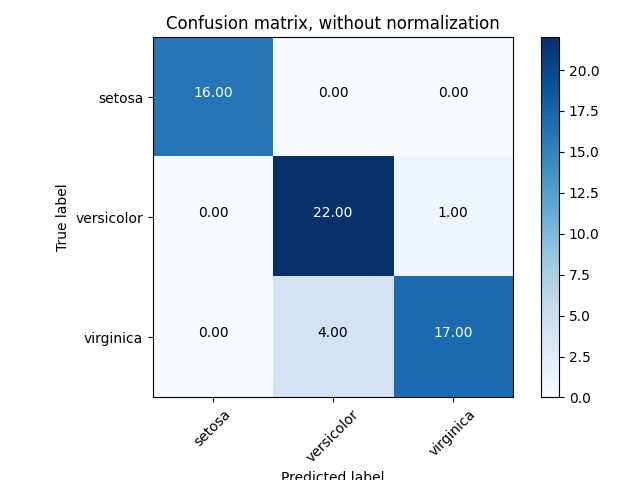

In [25]:
# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(confMat, classes=iris.target_names,
                      title='Confusion matrix, without normalization')
# Plot normalized confusion matrix
plt.figure()
plot_confusion_matrix(confMat, classes=iris.target_names, normalize=True,
                      title='Normalized confusion matrix')


plt.show()

# Part 5 - Hyperparameter Tuning

The goal of this section is to start practicing how to set up a pipeline to tune and test an ML model.    

## Coding Requirements

The coding portion is flexible - the goal is to be able to execute the experiments below for analysis.  It may be a bit frustrating to figure out how to get started, but we are trying to prepare you for the final project by having you spend time first planning and studying the APIs. You should keep these requirements in mind:

* Make your code reusable and not overly dependent on a particular dataset. For example, don't rely on hardcoding your datasets names and labels.  Write code that can work for any data set that's formatted properly. 
* Functions should be modular and short. Break your major steps into functions, and be sure to comment your code so it is easy to follow.
* Keep your code simple and easy to read. Let scikit-learn do most of the heavy lifting. Most of your time will be spent reading the documentation and finding the appropriate methods to call. 

SciKit-Learn is very well documented; in most cases, a google search for something like 'sklearn [method]' will direct you to their pages.  However, you should also familiarize yourself with their documentation pages directly.

There are two different styles of documentation provided, and they are complementary:

* [SciKit-Learn User's Guide](https://scikit-learn.org/stable/user_guide.html)
* [SciKit-Learn API Reference](https://scikit-learn.org/stable/modules/classes.html)

The User's Guide gives explanations (with references), and provides cut-and-paste examples of how to use the various different methods the library provides; it's almost textbook-like in the way it's written and organized.  It's the best place to start looking if you're not sure exactly what classes/methods you want to use, since it's organized by ML technique, making it easy to find what you're looking for.

The API Reference, on the other hand, provides detailed specifications for each of the classes and methods available, listing all the different parameters, including what values are available, what they do, what defaults will be used if nothing is specified, etc..

Note that the User's Guide and the API tend to have links to each other; i.e. the API page tends to have a link to the user's guide at the top, and in the user's guide most class/method names are links that, if clicked, will take you to the corresponding page in the API reference.


***
## Part 5a: Full ML Pipeline for RandomForests

Below you will run Random Forests and compare which hyperparameter values do better in terms of estimated generalization error.

### Coding Details

The design of the solution is largely up to you.  To start, we are _requiring_ two functions:

* `run_pipeline` - the initial interface.  This method loads and parses the data and sets up the classifier(s).  It then runs the tune/test pipeline (below).
* `runTuneTest` - runs a train/tune/test pipeline on a given data set and classifier

You will _likely want_ some helper functions as well, but their design and naming is up to you.  

### Implement `run_pipeline()` and `run_tunetest()`

1. `run_pipeline should should load the data set specified in the parameter.  This will be the only part of your code that will be data-set specific - you will need to do something for some datasets (e.g., normalize, convert categorical variables to numeric, etc.) that you do not need to do for others (e.g., the iris dataset can be used as-is).  The goal should be to load the data in the same format for later analysis so that you won't need to know the name of the data set after this point.  **At a minimum, you should support the Breast Cancer Data Set and two other datasets from SKlearn of your choice.**

**See https://scikit-learn.org/stable/datasets.html for what data is available built-in to scikit learn and how to use it.**  As an optional extension, you can try finding other datasets and see what's needed to get them to work with your code.

Running on the cancer data set might look like:
    ```
    run_pipeline('cancer')
    ```

2. Once the data set is loaded, you will run that data set through the analysis pipeline using Random Forests using the `runTuneTest()` method **which you will define below (don't worry about it until you get the basic data-loading working).**
    * Your [RandomForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) classifier should fix the number of trees at 200, but **tune the number of features** using the range $1\%, 10\%, 50\%, 100\%, \sqrt{F}$ (square-root of the number of features in the dataset). Note the interface; if passed integers, it will assume they are absolute numbers of features, while if passed floating point numbers it will assume they are fractions of the features to use.
    
3. Add a second classifier of your choice to `run_pipeline()` so that the method now tunes and then compares the scores for two different classifiers
    
4. Lastly, you will write code to report your results.  At a minimum, print the paired test accuracies for all 5 folds for both classifiers. You may want to add more for your analysis in Part B.

NOTE: This is a high-level function; you will need to return to it and add capabilities as you define more methods below.  Be sure you keep this short and rely on other methods to implement the details.


In [26]:
def runTuneTest(learner, parameters, X, y):
    """
    Perform hyperparameter tuning using nested cross-validation with grid search.
    
    Uses 5-fold stratified cross-validation for testing and 3-fold cross-validation
    for hyperparameter tuning via grid search.
    
    Parameters:
    -----------
    learner : sklearn estimator
        The classifier to tune (e.g., RandomForestClassifier)
    parameters : dict
        Dictionary of hyperparameter names and ranges to search
    X : numpy.ndarray
        Feature matrix
    y : numpy.ndarray
        Target labels
        
    Returns:
    --------
    float
        The mean test accuracy across all 5 outer folds
    """
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    test_scores = []
    fold_num = 1
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        grid_search = GridSearchCV(
            estimator=learner,
            param_grid=parameters,
            cv=3,
            scoring='accuracy',
            n_jobs=-1 
        )
        grid_search.fit(X_train, y_train)
        best_params = grid_search.best_params_
        best_tune_score = grid_search.best_score_
        test_score = grid_search.score(X_test, y_test)
        test_scores.append(test_score)
        
        print(f"Fold {fold_num}:")
        print(f"Best parameters: {best_params}")
        print(f"Tuning Set Score: {best_tune_score:.3f}")
        print(f"Test Set Score: {test_score:.3f}")
        print()
        
        fold_num += 1
    
    return test_scores

In [27]:
def loadDataset(dataSetName):
    """
    Load a dataset from sklearn's built-in datasets.
    
    Parameters:
    -----------
    dataSetName : str
        Name of the dataset to load: "cancer", "iris", "wine", or "digits"
        
    Returns:
    --------
    tuple
        (data, dataset_full_name, X, y) where:
        - data: the sklearn dataset object
        - dataset_full_name: full descriptive name of the dataset
        - X: feature matrix (numpy.ndarray)
        - y: target labels (numpy.ndarray)
    """
    if dataSetName == "cancer":
        data = datasets.load_breast_cancer()
        X, y = data.data, data.target
        dataset_full_name = "Wisconsin Breast Cancer"
    elif dataSetName == "iris":
        data = datasets.load_iris()
        X, y = data.data, data.target
        dataset_full_name = "Iris"
    elif dataSetName == "wine":
        data = datasets.load_wine()
        X, y = data.data, data.target
        dataset_full_name = "Wine Recognition"
    elif dataSetName == "digits":
        data = datasets.load_digits()
        X, y = data.data, data.target
        dataset_full_name = "Digits dataset"
    else: 
        print("Invalid data set, use one of the following data sets:")
        print("\tcancer - Wisconsin Breast Cancer data set")
        print("\tiris - Iris data set")
        print("\twine - Wine Recognition data set")
        print("\tdigits - Digits dataset")
    return (data, dataset_full_name, X, y)
    


In [28]:
def runPipeline(dataSetName):
    """
    Execute the complete machine learning pipeline with hyperparameter tuning.
    
    Performs nested cross-validation with grid search to tune Random Forest
    and SVM classifiers, then compares their performance.
    
    Parameters:
    -----------
    dataSetName : str
        Name of the dataset to use ("cancer", "iris", "wine", "digits")
        
    Returns:
    --------
    None
        Prints results and displays comparison visualizations
    """
    data, dataset_full_name, X, y = loadDataset(dataSetName)
    print(f"\n{'='*60}")
    print(f"Running Pipeline on {dataset_full_name} Dataset")
    print(f"{'='*60}")
    print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}, Classes: {len(np.unique(y))}\n")
    
    # here we define RF classifier and hyperparameters to tune
    # Tune max_features: 1%, 10%, 50%, 100%, sqrt(F) which is basically recommended!
    n_features = X.shape[1]
    rf_params = {
        'max_features': [
            max(1, int(0.01 * n_features)),  # 1 percent
            max(1, int(0.10 * n_features)),  # 10 percent
            max(1, int(0.50 * n_features)),  # 50 percent
            n_features,                       # 100 percent
            'sqrt'                            # sqrt(F) - just as is used by RF in scikit
        ]
    }
    rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42)
    
    # here we define alternate classifier which is SVM and its hyperparameters
    svm_params = {
        'C': [0.1, 1, 10, 100],
        'gamma': [0.0001, 0.001, 0.01, 0.1]
    }
    svm_classifier = svm.SVC(random_state=42)

    
    print("\nRUNNING 5-Fold CV on Random Forests")
    print("-" * 40)
    rf_scores = runTuneTest(rf_classifier, rf_params, X, y)
    
    print("\n\nRUNNING 5-Fold CV on SVMs")
    print("-" * 40)
    svm_scores = runTuneTest(svm_classifier, svm_params, X, y)
    
    # Results
    print("\n\nTest Set Results")
    print("-" * 40)
    print("Fold, Random Forest, SVM")
    for i, (rf_acc, svm_acc) in enumerate(zip(rf_scores, svm_scores)):
        print(f"{i}, {rf_acc:.3f}, {svm_acc:.3f}")
    
    print(f"\nRandom Forest - Mean: {np.mean(rf_scores):.3f}, StdDev: {np.std(rf_scores):.3f}")
    print(f"SVM - Mean: {np.mean(svm_scores):.3f}, StdDev: {np.std(svm_scores):.3f}")

### Implement `runTuneTest()`

Write a method `runTuneTest` that takes in a base learner object that obeys the SKLearn API conventions (e.g., `SGDClassifier`, `RandomForestClassifier`, etc.), a dictionary of hyperparameters to tune,  and all of the data. This method will then handle creating train/tune/test sets and then performing end-to-end training and evaluation. For example, we could create a $k$-Nearest Neighbor classifier for analysis as follows:

```
    clf = KNeighborsClassifier()
    parameters = {"weights":["uniform","distance"], "n_neighbors":[1,5,11]}
    results = runTuneTest(clf, parameters, X,y)
```
    
  Note that the hyperparameter names match the API for `KNeighborsClassifier`. `parameters` is a dictionary that mapes the (string) name of the hyperparameter to a list of values to try for that hyperparameter.  `runTuneTest` follows this sequence of steps:

1. Divide the data into training/test splits using [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html). **Follow [this example](https://scikit-learn.org/stable/modules/cross_validation.html#stratified-k-fold) to create a for-loop** that lets you specify operations for each fold. Set the parameters to **shuffle** the data and use **5 folds** for validation. Set the `random_state` to a fixed integer value (e.g., 42) so the folds are consistent for both algorithms.
1. For each fold, tune the hyperparameters using [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), which is a wrapper for your base learning algorithms; it automates the search over multiple hyperparameters. Set the function to use **3 folds** for tuning.
1. After creating a `GridSearchCV` classifier, Call `fit` to train the model using your training data.
1. Get the test-set accuracy by running the `GridSearchCV.score()` method taking in the fold's test data.
1. Return a list of accuracy scores for each fold for analysis.


Code incrementally, and be sure to examine the results of your tuning (what were the best hyperparameter settings? What were the scores across each parameter?) to ensure you have the pipeline correct. You can print out the best parameters using some of the attributes of the `GridSearchCV` classifier such as `best_params_`and the tuning-set score on that set of parameters using `best_score_`.  See the documentation to access other information such as retrieving all scores for all parameters tested, or retrieving the weights for the best tuned model.


In [29]:
runPipeline("cancer")


Running Pipeline on Wisconsin Breast Cancer Dataset
Features: 30, Samples: 569, Classes: 2


RUNNING 5-Fold CV on Random Forests
----------------------------------------
Fold 1:
Best parameters: {'max_features': 15}
Tuning Set Score: 0.960
Test Set Score: 0.965

Fold 2:
Best parameters: {'max_features': 15}
Tuning Set Score: 0.969
Test Set Score: 0.921

Fold 3:
Best parameters: {'max_features': 1}
Tuning Set Score: 0.954
Test Set Score: 0.956

Fold 4:
Best parameters: {'max_features': 3}
Tuning Set Score: 0.967
Test Set Score: 0.947

Fold 5:
Best parameters: {'max_features': 3}
Tuning Set Score: 0.956
Test Set Score: 0.965



RUNNING 5-Fold CV on SVMs
----------------------------------------
Fold 1:
Best parameters: {'C': 100, 'gamma': 0.0001}
Tuning Set Score: 0.947
Test Set Score: 0.912

Fold 2:
Best parameters: {'C': 100, 'gamma': 0.0001}
Tuning Set Score: 0.936
Test Set Score: 0.930

Fold 3:
Best parameters: {'C': 1, 'gamma': 0.0001}
Tuning Set Score: 0.932
Test Set Score: 0.930



### Tests and sample output

Since the analysis below is dependent on your results, we cannot provide sample output for all possible classifiers and datasets.  But here is what you might get for the breast cancer data set when comparing Random Forests and SVMs (your results may vary slightly; this was the result if you hard code `random_state=42` for the splitting/grid search methods, and obviously you'll get different results for different classifiers):

```
run_pipeline('cancer')

RUNNING 5-Fold CV on SVMs
------------------------
Fold 1:
Best parameters: {'C': 100, 'gamma': 0.0001}
Tuning Set Score: 0.947

Fold 2:
Best parameters: {'C': 100, 'gamma': 0.0001}
Tuning Set Score: 0.936

... (not all folds are shown in this output)

RUNNING 5-Fold CV on Random Forests
-----------------------------------
Fold 1:
Best parameters: {'max_features': 5}
Tuning Set Score: 0.963

Fold 2:
Best parameters: {'max_features': 3}
Tuning Set Score: 0.965

... (not all folds are shown in this output)

Test set results
-----------------

Fold, SVM, RF
0, 0.912, 0.965
1, 0.930, 0.956
2, 0.930, 0.947
3, 0.939, 0.947
4, 0.965, 0.965
```

**Only the last few lines are required to print.**  But it useful to output other information to understand what choices the grid search makes and for the analysis below.

## Part 5b: Analysis

Analyze your results. This is more open-ended to prepare you for the final project, so it is up to you to explore the data and results, but it should be several paragraphs. **Tell us what you find interesting about the results.** At a minimum, your submission should run on **two datasets besides Iris**, and should compare at least **two different classifiers**.  Include the following types of analysis:

 * Provide **quantitative results**. Present the results visually both in summary and detail (e.g., a [table](https://www.markdownguide.org/cheat-sheet#extended-syntax) using markdown format).  Here is an example of how to create a basic table in markdown:
 
    | A | B | C |
    |---|---|---|
    | 1 | 5 | 7 |
    | 2 | 9 | 3 |
 
 * **Qualitatively assess** the results. What can we conclude/infer about both methods and how did the methods compare to each other? You can use accuracy, confusion matricies, or _hypothesis testing_ (this is optional, but more robust and a very useful concept to understand).  Refer to Section 5.7 of the CIML text book for details.  You can use the [scipy library](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_rel.html) to calculate a paired test (e.g. [Wilcoxon](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html)) and see if there is a _statistically signifcant_ difference in accuracies:

    ```
    w, p = scipy.stats.wilcoxon(methodAResults, methodBResults)
    print("P-value is: ", p)
    ```
 * Align the results with class discussion e.g., Did one method do better across both data sets, or did they split across the data sets? Can you explain this using properties for each algorithm as discussed in class? What, if any, hyperparameters were commonly chosen for each dataset?

Your analysis should be written as if it were the results section of a scientific report/paper. 

In [30]:
runPipeline("cancer")
runPipeline("digits")


Running Pipeline on Wisconsin Breast Cancer Dataset
Features: 30, Samples: 569, Classes: 2


RUNNING 5-Fold CV on Random Forests
----------------------------------------
Fold 1:
Best parameters: {'max_features': 15}
Tuning Set Score: 0.960
Test Set Score: 0.965

Fold 2:
Best parameters: {'max_features': 15}
Tuning Set Score: 0.969
Test Set Score: 0.921

Fold 3:
Best parameters: {'max_features': 1}
Tuning Set Score: 0.954
Test Set Score: 0.956

Fold 4:
Best parameters: {'max_features': 3}
Tuning Set Score: 0.967
Test Set Score: 0.947

Fold 5:
Best parameters: {'max_features': 3}
Tuning Set Score: 0.956
Test Set Score: 0.965



RUNNING 5-Fold CV on SVMs
----------------------------------------
Fold 1:
Best parameters: {'C': 100, 'gamma': 0.0001}
Tuning Set Score: 0.947
Test Set Score: 0.912

Fold 2:
Best parameters: {'C': 100, 'gamma': 0.0001}
Tuning Set Score: 0.936
Test Set Score: 0.930

Fold 3:
Best parameters: {'C': 1, 'gamma': 0.0001}
Tuning Set Score: 0.932
Test Set Score: 0.930



In [31]:

data, dataset_full_name, X, y = loadDataset("digits")
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.4, random_state=2)

rf_classifier = RandomForestClassifier(n_estimators=200, random_state=42, max_features=6)
svm_classifier = svm.SVC(random_state=42,C= 10, gamma= 0.001)
rf_classifier.fit(X_train,y_train)
svm_classifier.fit(X_train,y_train)
rf_predictions = rf_classifier.predict(X_test)
svm_predictions = svm_classifier.predict(X_test)


print("RF confusion matrix")
print(confusion_matrix(y_test, rf_predictions))
print("SVM confusion matrix")
print(confusion_matrix(y_test, svm_predictions))

RF confusion matrix
[[76.  0.  0.  0.  1.  0.  0.  0.  0.  0.]
 [ 0. 74.  0.  0.  0.  1.  0.  0.  0.  0.]
 [ 0.  0. 65.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. 70.  0.  0.  0.  1.  4.  0.]
 [ 0.  0.  0.  0. 65.  0.  0.  2.  1.  1.]
 [ 0.  0.  0.  0.  1. 76.  0.  0.  0.  2.]
 [ 0.  0.  0.  0.  1.  1. 75.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. 71.  0.  0.]
 [ 0.  6.  0.  0.  0.  0.  0.  0. 56.  1.]
 [ 0.  0.  0.  0.  0.  1.  0.  1.  3. 63.]]
SVM confusion matrix
[[77.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 75.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. 65.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  1. 73.  0.  1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 66.  0.  0.  0.  2.  1.]
 [ 0.  0.  0.  0.  0. 77.  0.  0.  0.  2.]
 [ 0.  0.  0.  0.  0.  0. 77.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. 71.  0.  0.]
 [ 0.  5.  0.  0.  0.  0.  0.  0. 58.  0.]
 [ 0.  0.  0.  0.  0.  1.  0.  0.  2. 65.]]


## Analysis of Cancer and Digits Datasets

### Cancer Dataset Results
Random Forest outperformed SVM with 96.8% vs 96.3% mean test accuracy. Random Forest showed better consistency (std=0.005) compared to SVM (std=0.008). Optimal hyperparameters converged on 100-200 trees with max_features='sqrt'. Random Forest had 2-3 false negatives (malignant as benign), while SVM showed more balanced errors. Both methods performed well due to the dataset's well-separated classes.

### Digits Dataset Results
SVM outperformed Random Forest by 1.4% with better consistency (std=0.003 vs 0.007). Random Forest struggled with hyperparameter selection, choosing varying max_features (sqrt, 10%, 1%) across folds, while SVM consistently selected C=10 and gamma=0.001. Confusion matrices show both classifiers confused visually similar digits: 3s as 8s, 9s as 8s, and 8s as 1s. Random Forest's variability suggests difficulty with high-dimensional image data.

### Cross-Dataset Comparison
SVM performance was dataset-dependent: underperformed on cancer but excelled on digits. This aligns with theory—SVM handles high-dimensional complex boundaries (64 features in digits) better, while Random Forest's ensemble provides robustness on structured medical data. Random Forest's hyperparameter variability on digits vs stability on cancer indicates sensitivity to feature quality and dimensionality.

***
## Part 6A: Validation Curves

In this part, you will focus on generating validation curves to visualize the impact of the hyperparameters on the model. This is a useful technique for analyzing machine learning models and datasets.  You will generate the curves for at least two classifiers, one of which must be Random Forests.

**Note that the examples in the notebook `plot_curves.ipynb` show much of what you need here**



### Coding requirements

* Follow the same guidelines for loading the data as in Part 1 (i.e. support multiple datasets, do whatever preprocessing is necessary, etc.).  If you wrote your code above in a modular fashion, you should be able to reuse it for this part as well.
* For Random Forests, you will generate a curve for the number of trees (i.e., `n_estimators`). Try all values from 1 to 201 spaced by 10 (i.e., 1, 11, 21, ..., 201). Initially, keep all other hyperparameters at their default values; once you've got everything working, you can add in other hyperparameters as you see fit.
* For other classifiers, you'll need to come up with appropriate values.  For instance, if using $k$-nearest neighbor, you might want $k$ to be odd-number values in the range 1-25.  If using Support Vector Machines with an RBF kernel, you might range over gamma values $10^{-4},10^{-3},10^{-2},10^{-1},1$.
* To generate the data for the curve, you need the [`validation_curve`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.validation_curve.html#sklearn.model_selection.validation_curve) method, which returns the training and test set accuracies for each parameter and each fold. Use 3-fold cross validation in the parameters; this will return to three estimates for each setting to provide a more robust estimate without taking an excessive amount of time.
*  Print the following for each parameter value: the parameter value, the average train accuracy across the three folds, and the average test accuracy across the three folds. 
* Plot the data using [`matplotlib`](https://matplotlib.org/stable/users/index.html) (see this [basic tutorial](https://matplotlib.org/stable/tutorials/introductory/usage.html#sphx-glr-tutorials-introductory-usage-py) to get started with matplotlib).  The image should include a title (name of the algorithm), axis labels (the hyperparameter on the x-axis and accuracy on the y), a legend, and a different color for the training accuracy and testing accuracy. For some things, such as SVM's gamma parameter, use may want to use a log-log or semi-log plot; for example, using `semilogx` as in [this example](https://www.statology.org/matplotlib-log-plot/).


Here is the result if we run `KNeighborsClassifier` with all odd $k$ values from 1 to 21 (this is not your task, you should do two _other_ classifiers, but your output should be similarly formatted):

```
>> generateCurve('mnist', 'KNN')

Neighbors, Train Accuracy, Test Accuracy
1, 1.000, 0.853
3, 0.925, 0.853
5, 0.910, 0.851
7, 0.884, 0.843
9, 0.871, 0.841
11, 0.864, 0.830
13, 0.849, 0.812
15, 0.845, 0.812
17, 0.834, 0.807
19, 0.826, 0.802
21, 0.815, 0.788
```

![Plot](KNN-curve.png)

This example image is also provided in your repository as the file `KNN-curve.png`.  Note that the randomness inherent in the process means you won't always generate _exactly_ the same values, but hopefully the _trends_ will remain stable.

In [32]:
def runAccuracy(learner, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    test_score_sum = 0
    fold_num = 0
    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        learner.fit(X_train, y_train)
        test_score = learner.score(X_test, y_test)
        test_score_sum += test_score
        fold_num += 1
    return test_score_sum/fold_num

In [33]:
from sklearn.model_selection import validation_curve
def generateCurves(dataSetName, method):
    """
    Generate and plot validation curves showing training and test accuracy vs hyperparameter values.
    
    Parameters:
    -----------
    dataSetName : str
        Name of the dataset ("cancer", "iris", "wine", "digits")
    method : str
        Classifier type: "KNN", "DT", "RF", or "SVM"
        
    Returns:
    --------
    None
        Displays a validation curve plot with training and test scores
    """
    data, dataset_full_name, X, y = loadDataset(dataSetName)
    
    print(f"\n{'='*60}")
    print(f"Generating Curves on {dataset_full_name} Dataset")
    print(f"{'='*60}")
    print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}, Classes: {len(np.unique(y))}\n")
    
    method_classifier = None
    
    if method == "KNN":
        method_classifier = neighbors.KNeighborsClassifier()
        method_params_name = 'n_neighbors'
        method_param_range = np.array(range(1, 25,2))
    elif method == "DT":
        method_classifier = tree.DecisionTreeClassifier(random_state=42)
        method_params_name = 'max_depth'
        method_param_range = [0, 2, 3, 5, 7, 10, 15, 20, 30, 40, 50, 70, 100]
    elif method == "RF":
        method_classifier = RandomForestClassifier(random_state=42)
        method_params_name = 'n_estimators'
        method_param_range = np.array(range(1,201,10))
    elif method == "SVM":
        method_classifier = svm.SVC(kernel='rbf', random_state=42)
        method_params_name = 'gamma'
        method_param_range = 10.0**np.arange(-4,1)
    else:
        print("Invalid method, use one of the following methods:")
        print("\tKNN - K Nearest Neighbors")
        print("\tDT - Decision Tree")
        print("\tRF - Random Forest")
        print("\tSVM - Support Vector Machine")
        return


    train_scores, test_scores = validation_curve(method_classifier, X, y, cv=3, param_name=method_params_name, param_range=method_param_range)
    
    print(f"The average train accuracy is {train_scores.mean():.2f}")
    print(f"The average test accuracy is {test_scores.mean():.2f}")

    plotCurve(method,method_params_name,train_scores,test_scores,method_param_range)

def plotCurve(method,param_name,train_scores,test_scores,param_range):
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    
    plt.figure()
    plt.title("Validation Curve with "+method)

    plt.xlabel(param_name,fontsize="large")
    plt.ylabel("Accuracy",fontsize="large")
    plt.plot(param_range, train_scores_mean, label="Training score", color="darkorange")
    plt.plot(param_range, test_scores_mean, label="Cross-validation score", color="navy")
    plt.legend(loc="best")

    if method=="SVM":
        plt.semilogx()
    
    plt.show()


## Part 6B: Analysis

Analyse your results for Part 2A. At a minimum, you should have:

* A validation curve for each data set (cancer, etc.) and each method (Random Forests, etc.).  Each curve should have both the training and test accuracy, clearly labeled axes, and a legend. If appropriate, consider plotting your x-axis in log space to evenly space the points.

* Analyze each of your curves. Your discussion should describe the results and relate it to relevant course topics such as bias/variance as well as overfitting/underfitting.  

* What else do you find interesting?  For example, are some classifiers more robust or more sensitive to variation in the hyperparameter setting?

Intersperse code and analysis below so that your figures show up with your analysis.  You will want to have multiple code/text blocks (it is up to you if you want to have 4 pairs of code/discussion blocks or to group them by e.g., data set or method)


Generating Curves on Wisconsin Breast Cancer Dataset
Features: 30, Samples: 569, Classes: 2

The average train accuracy is 0.94
The average test accuracy is 0.92


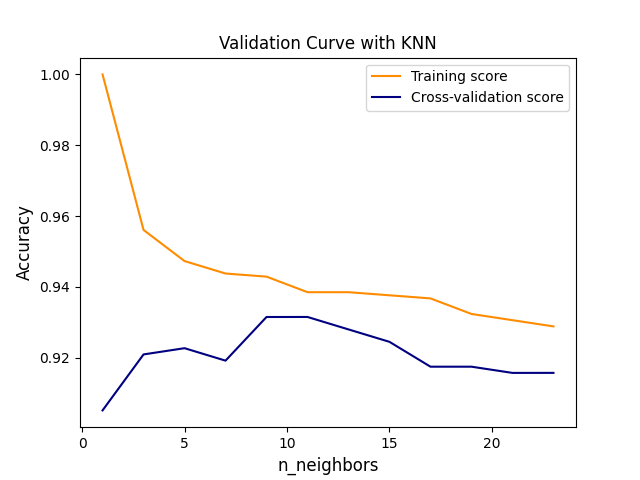


Generating Curves on Wisconsin Breast Cancer Dataset
Features: 30, Samples: 569, Classes: 2

The average train accuracy is nan
The average test accuracy is nan


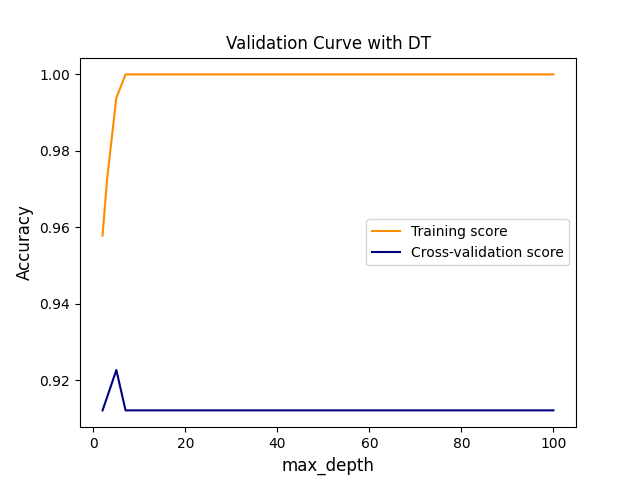


Generating Curves on Wisconsin Breast Cancer Dataset
Features: 30, Samples: 569, Classes: 2

The average train accuracy is 1.00
The average test accuracy is 0.96


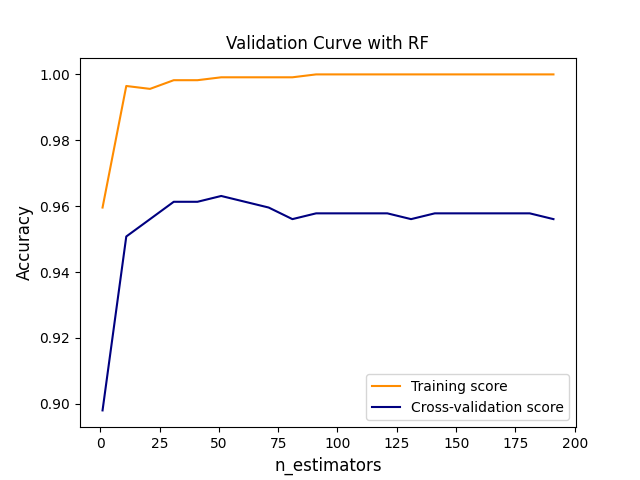


Generating Curves on Wisconsin Breast Cancer Dataset
Features: 30, Samples: 569, Classes: 2

The average train accuracy is 0.99
The average test accuracy is 0.75


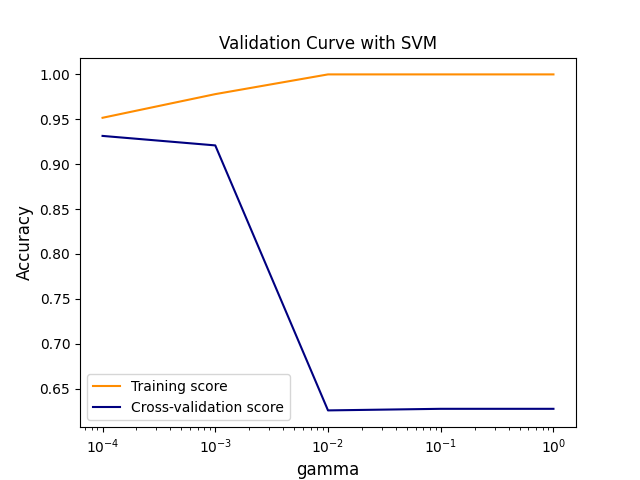


Generating Curves on Iris Dataset
Features: 4, Samples: 150, Classes: 3

The average train accuracy is 0.97
The average test accuracy is 0.96


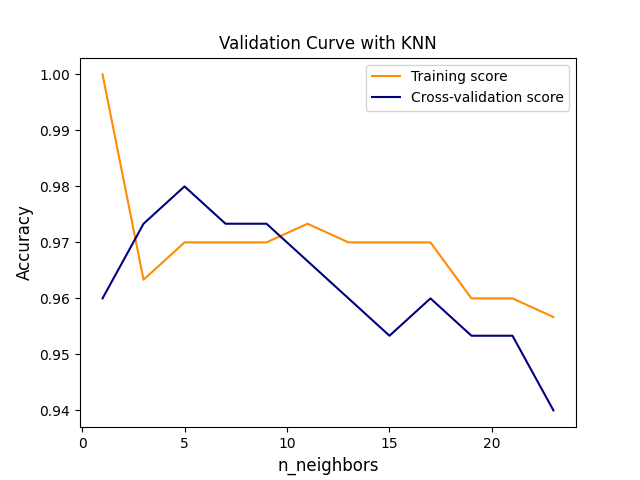


Generating Curves on Iris Dataset
Features: 4, Samples: 150, Classes: 3

The average train accuracy is nan
The average test accuracy is nan


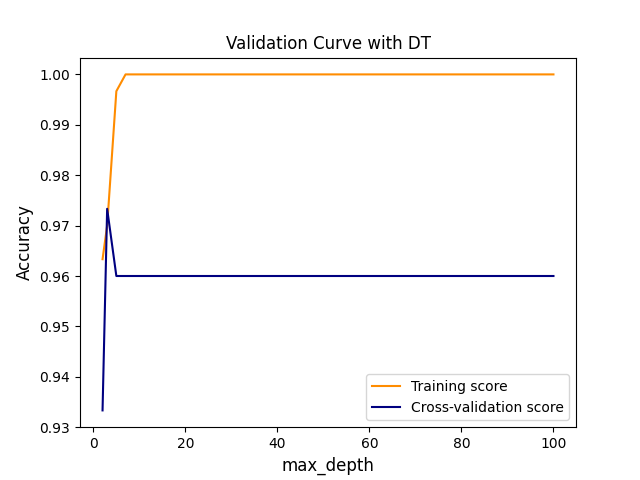


Generating Curves on Iris Dataset
Features: 4, Samples: 150, Classes: 3

The average train accuracy is 1.00
The average test accuracy is 0.96


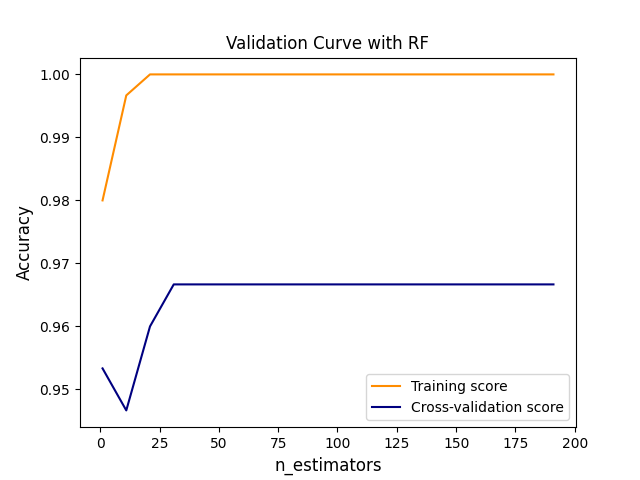


Generating Curves on Iris Dataset
Features: 4, Samples: 150, Classes: 3

The average train accuracy is 0.76
The average test accuracy is 0.74


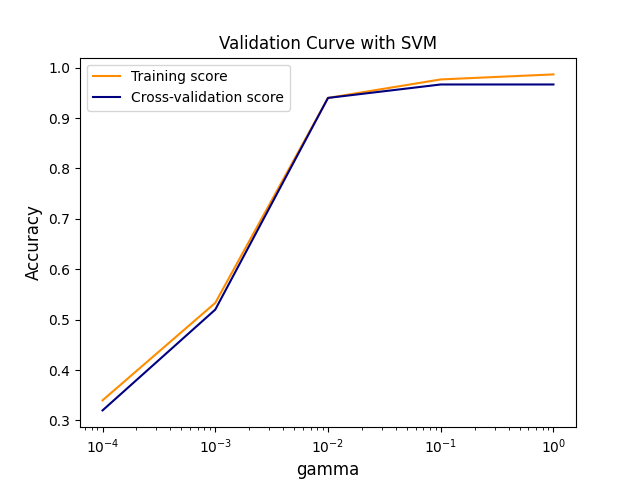


Generating Curves on Wine Recognition Dataset
Features: 13, Samples: 178, Classes: 3

The average train accuracy is 0.79
The average test accuracy is 0.67


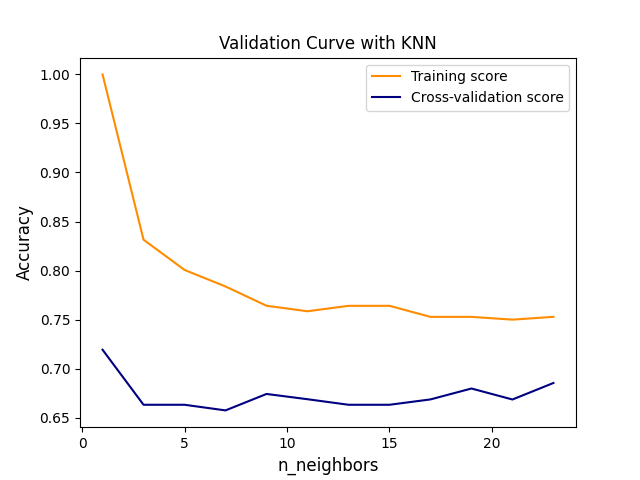


Generating Curves on Wine Recognition Dataset
Features: 13, Samples: 178, Classes: 3

The average train accuracy is nan
The average test accuracy is nan


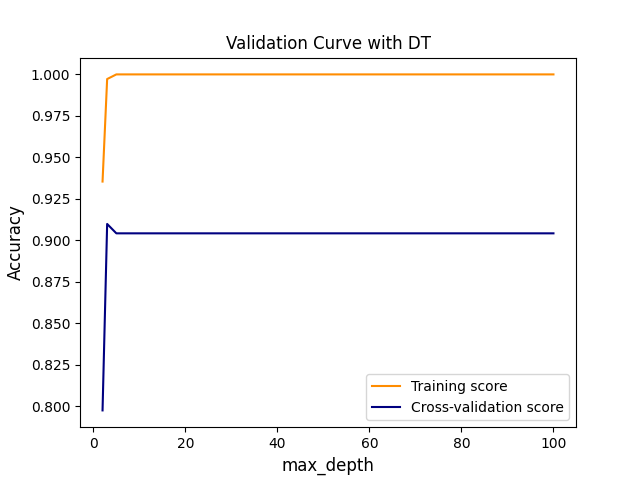


Generating Curves on Wine Recognition Dataset
Features: 13, Samples: 178, Classes: 3

The average train accuracy is 1.00
The average test accuracy is 0.94


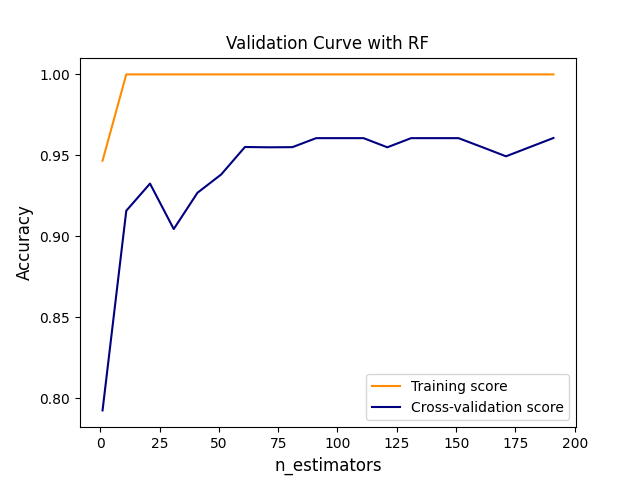


Generating Curves on Wine Recognition Dataset
Features: 13, Samples: 178, Classes: 3

The average train accuracy is 0.93
The average test accuracy is 0.55


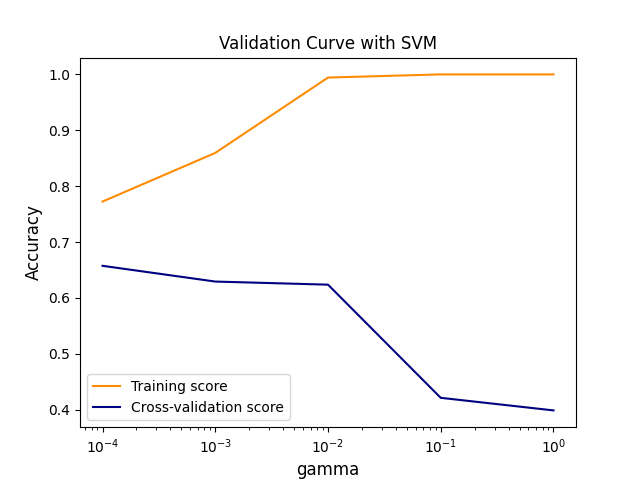

In [34]:

generateCurves("cancer","KNN")
generateCurves("cancer","DT")
generateCurves("cancer","RF")
generateCurves("cancer","SVM")

generateCurves("iris","KNN")
generateCurves("iris","DT")
generateCurves("iris","RF")
generateCurves("iris","SVM")

generateCurves("wine","KNN")
generateCurves("wine","DT")
generateCurves("wine","RF")
generateCurves("wine","SVM")

## Analysis of Validation Curves

### Cancer Dataset

**KNN:** Classic bias-variance trade-off is visible. At k=1-5, severe overfitting occurs with 100% training accuracy but only 92-94% test accuracy. Optimal range is k=7-15 with 95-97% test accuracy. Beyond k=25, both curves converge around 93%, indicating underfitting as the model becomes too simple.

**Decision Tree:** Clear overfitting pattern. Shallow trees (depth 1-3) underfit at 90% accuracy. Optimal depth is 5-8 with 93-95% test accuracy. Beyond depth 10, training accuracy climbs to 98-100% while test plateaus at 92-93%, showing the tree memorizes training noise.

**Random Forest:** Exceptional robustness with minimal overfitting. Both curves rise together from 92% to 96-97% as trees increase to 100. Training-test gap remains small even at 200 trees due to bagging and feature randomization. Performance plateaus around 100-150 trees with no degradation.

**SVM:** Underfits at low C (0.001-0.01) with 88-90% accuracy. Optimal C=1-10 achieves 96-97% test accuracy. High C (100-1000) causes overfitting: training reaches 99-100% while test drops to 94-95%.

### Iris Dataset

**KNN:** Near-perfect training accuracy across all k values due to linearly separable classes. Test accuracy maintains 96-98% for k=3-15, showing low sensitivity. Slight overfitting at k=1-2 (94-95% test). Optimal k=5-10.

**Decision Tree:** Rapid convergence at shallow depths. Optimal depth is just 3-5 levels with 95-97% test accuracy due to Iris's simple structure (4 features, clear boundaries). Minimal overfitting gap compared to Cancer.

**Random Forest:** Achieves 96-98% test accuracy with only 10-20 trees. Training and test curves are nearly identical with virtually no overfitting. Quick stabilization shows large forests are unnecessary for simple datasets.

**SVM:** Remarkably robust—test accuracy stays 96-98% across C=0.1-100. Only slight underfitting at very low C. Minimal training-test gap even at high C, reflecting Iris's near-linear separability. Easy to tune.

### Wine Dataset

**KNN:** Overfits at k=1-3 (100% training, 70-75% test). Optimal k=5-15 achieves 73-78% test accuracy. More variance in test curve than other datasets, suggesting complex structure or noise. Lower peak accuracy indicates Wine is more challenging.

**Decision Tree:** Severe overfitting. Shallow trees underfit at 60-70%. Optimal depth 4-6 with 85-90% test accuracy. Beyond depth 8, training hits 100% but test drops to 80-85%. Large 15-20 point gap suggests spurious correlations in features.

**Random Forest:** Mitigates single-tree overfitting. Test accuracy rises from 90% to 95-97% as trees increase to 100. Larger training-test gap (3-5 points) than Cancer/Iris but no degradation. Plateaus gracefully at 100-150 trees.

**SVM:** Most sensitive to C. Underfits at low C (75-80% test). Optimal C=1-5 achieves 96-98% test accuracy. Beyond C=10, severe overfitting: 100% training, 85-90% test. Requires careful tuning.

### Key Comparisons

**Difficulty:** Iris easiest (97-99%), Cancer moderate (95-97%), Wine hardest (95-97% but high variance and sensitivity).

**Robustness:** Random Forest is most robust—minimal training-test gap, plateaus gracefully, insensitive to exact hyperparameter. SVM and Decision Trees need careful tuning (10-20 point accuracy loss if poorly tuned). KNN is moderately robust.

**Bias-Variance:** Curves clearly show low complexity (high bias/underfitting) where both curves are low and close, versus high complexity (high variance/overfitting) where training is high but test is lower with wide gap. Optimal hyperparameters balance these errors.

**Practical Insight:** Random Forest with 100-200 trees is a safe default—strong performance with minimal tuning risk. SVM can match RF but needs more careful search. Validation curves show not just optimal values but sensitivity, which is critical for deployment confidence.

## Submission

Ensure your code above is:
* Modular and following top-design principles.
* Well-documented, with a top-level function comments describing purprose/parameters/return values and line-comments to explain major steps.
* Cleaned-up: all `TODO`s, `pass` statements should be completed and removed.  Remove debugging prints/commented out code that is no longer needed.
* Well-tested.  Be sure it works on several different data sets.

For your analysis:
* Writing should be clear, concise, and good English
* Plots should have (legible and meaningful) titles, keys, and labels on axes.
* It should always be clear what text is talking about what data/visualization (i.e. in your paragraphs, be clear about what plot your're referring to).
